---
## 실습 1 - 환경 준비와 첫 그래프
`한글 폰트 설정 후 리스트로 첫 선 그래프 출력`

적용된 폰트: ['Malgun Gothic']


������ ��θ� ã�� �� �����ϴ�.


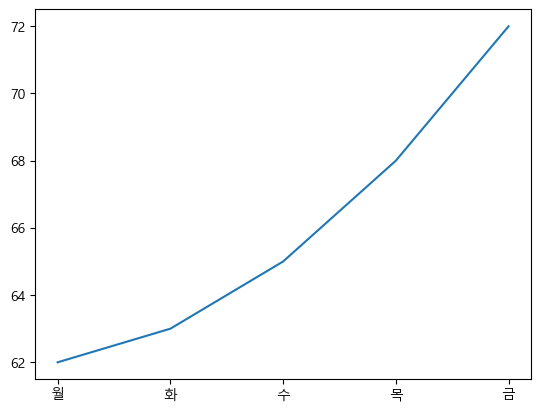

In [16]:
# pyplot을 plt 별칭으로 불러오기
import os
import platform
import pandas as pd
import matplotlib.pyplot as plt

# Colab(Linux)이면 나눔고딕을 먼저 설치 (로컬 Windows면 이 줄은 무시해도 됨)
!apt-get install -y fonts-nanum > /dev/null 2>&1

# rcParams로 한글 폰트를 설정해 글자 깨짐 방지
# Colab(Linux)과 로컬(Windows)에서 폰트 이름이 달라서 OS를 보고 골라줌
import matplotlib.font_manager as fm

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"  # 맑은 고딕
else:
    nanum_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    if os.path.exists(nanum_path):
        fm.fontManager.addfont(nanum_path)
        plt.rcParams["font.family"] = "NanumGothic"
    else:
        print("나눔고딕을 못 찾음 -> 런타임 재시작 후 이 셀을 다시 실행하세요")

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 안 깨지게
print("적용된 폰트:", plt.rcParams["font.family"])

# 요일, 온도 리스트를 plot으로 그리고 화면에 표시
요일 = ["월", "화", "수", "목", "금"]
온도 = [62, 63, 65, 68, 72]

plt.plot(요일, 온도)
plt.show()

---
## 실습 2 - 선 그래프 직접 그리기
`색, 선 스타일, 마커를 바꿔 가며 선 그래프 그리기`

<class 'pandas.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   측정시각    44 non-null     str    
 1   배치      44 non-null     str    
 2   온도      44 non-null     float64
 3   OP값     44 non-null     float64
 4   CP값     44 non-null     float64
 5   상태      44 non-null     str    
dtypes: float64(3), str(3)
memory usage: 2.2 KB


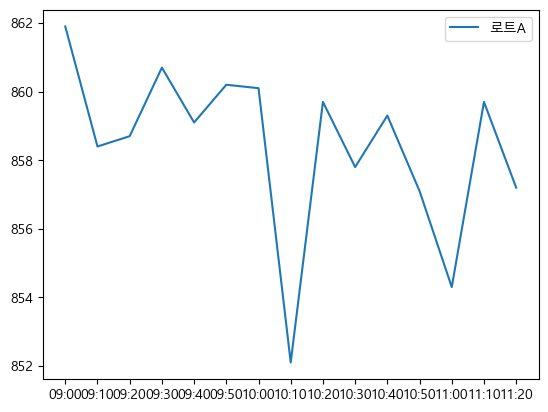

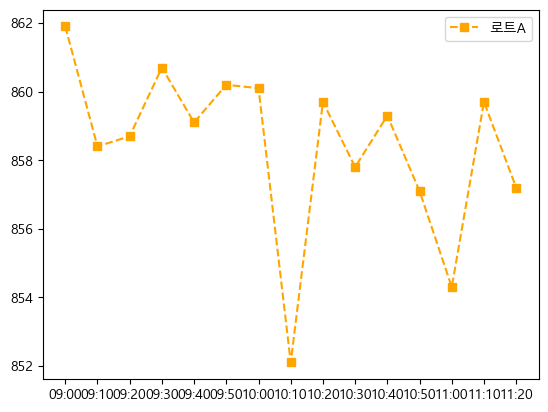

In [17]:
# 설비 데이터를 불러와 로트A 행만 고르기
# Colab에서는 CSV를 노트북과 같은 위치에 올려두고, 로컬에서는 ../Data 에서 읽음
DATA_DIR = os.path.join("..", "Data") if os.path.isdir(os.path.join("..", "Data")) else "."

path_2 = os.path.join(DATA_DIR, "17_열처리.csv")
df_2 = pd.read_csv(path_2, encoding="utf-8")
df_2.info()

df_2_a = df_2[df_2["배치"] == "로트A"]

# 일자와 온도로 기본 선 그래프 그리기
plt.plot(df_2_a["측정시각"], df_2_a["온도"], label="로트A")
plt.legend()
plt.show()

# color, linestyle, marker로 선을 꾸며 다시 그리기
plt.plot(df_2_a["측정시각"], df_2_a["온도"], label="로트A",
         color="orange",
         linestyle="--",
         marker="s")
plt.legend()
plt.show()

---
## 실습 3 - 센서값 추세 선 그래프
`실데이터로 한 설비 추세와 두 설비 비교 그리기`

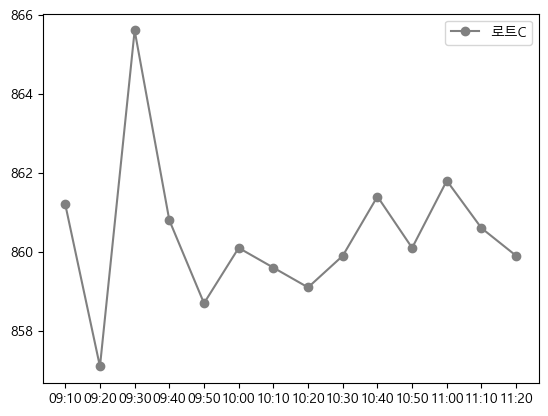

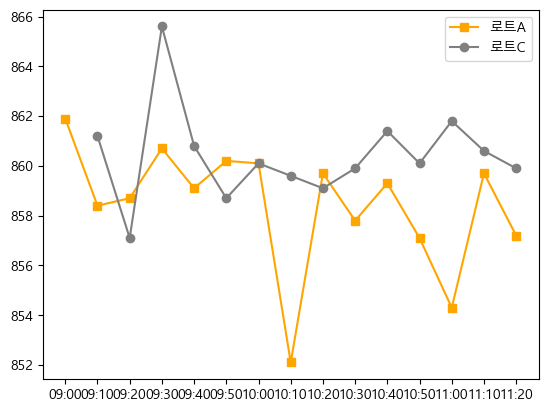

In [18]:
# 로트C 행을 골라 마커를 붙인 온도 추세 그리기
path_3 = os.path.join(DATA_DIR, "17_열처리.csv")
df_3 = pd.read_csv(path_3, encoding="utf-8")

df_3_a = df_3[df_3["배치"] == "로트A"]
df_3_c = df_3[df_3["배치"] == "로트C"]

plt.plot(df_3_c["측정시각"], df_3_c["온도"], label="로트C", color="gray", marker="o")
plt.legend()
plt.show()

# 로트A와 로트C를 겹쳐 그리고 각 선에 이름표 달기
# legend로 범례를 표시해 어느 선이 어느 설비인지 구분
plt.plot(df_3_a["측정시각"], df_3_a["온도"], label="로트A", color="orange", marker="s")
plt.plot(df_3_c["측정시각"], df_3_c["온도"], label="로트C", color="gray", marker="o")
plt.legend(loc="upper right")
plt.show()

---
## 실습 4 - 제목·축·범례 갖춘 완성형 그래프
`제목, 축 이름, 범례를 모두 갖춘 읽히는 그래프 완성`

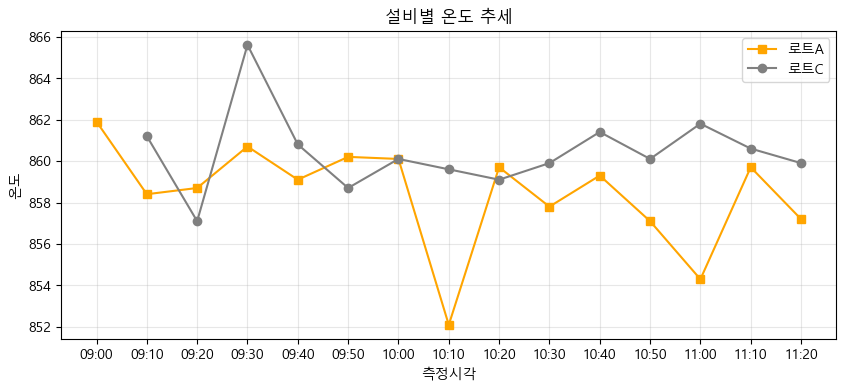

In [19]:
# figsize로 가로로 긴 그래프 틀 만들기 (plot보다 먼저 호출해야 적용됨)
path_4 = os.path.join(DATA_DIR, "17_열처리.csv")
df_4 = pd.read_csv(path_4, encoding="utf-8")

df_4_a = df_4[df_4["배치"] == "로트A"]
df_4_c = df_4[df_4["배치"] == "로트C"]

plt.figure(figsize=(10, 4))

# 두 설비를 색, 마커를 달리해 겹쳐 그리기
plt.plot(df_4_a["측정시각"], df_4_a["온도"], label="로트A", color="orange", marker="s")
plt.plot(df_4_c["측정시각"], df_4_c["온도"], label="로트C", color="gray", marker="o")

# 제목, 가로축, 세로축 이름과 범례 위치를 지정
plt.title("설비별 온도 추세")
plt.xlabel("측정시각")
plt.ylabel("온도")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)  # alpha 투명도

plt.show()

---
## 실습 5 - 다중 센서 비교 그래프와 저장
`반복문으로 세 설비를 비교하고 이미지로 저장`

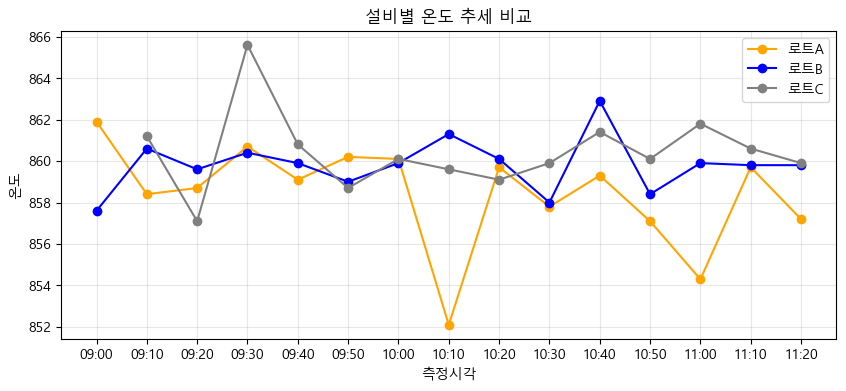

In [20]:
# 설비 이름과 색 목록을 반복하며 각 설비 온도 선 그리기
path_5 = os.path.join(DATA_DIR, "17_열처리.csv")
df_5 = pd.read_csv(path_5, encoding="utf-8")

plt.figure(figsize=(10, 4))

names = [("로트A", "orange"),
         ("로트B", "blue"),
         ("로트C", "gray")]

for (name, color) in names:
    df_name = df_5[df_5["배치"] == name]
    plt.plot(df_name["측정시각"], df_name["온도"], label=name, color=color, marker="o")

# 제목, 축 이름, 범례로 그래프를 완성
plt.title("설비별 온도 추세 비교")
plt.xlabel("측정시각")
plt.ylabel("온도")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

# savefig로 그래프를 이미지 파일로 저장 (show보다 먼저 호출해야 빈 파일이 안 됨)
plt.savefig("17_01_실습5_설비별_온도추세.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 실습 6 - 선 그래프 자유 변형
`한 설비의 여러 센서를 한 그래프에 종합해 그리기`

            온도     OP값     CP값
count   14.000  14.000  14.000
mean   860.421  69.621   0.452
std      1.914  21.974   0.009
min    857.100   7.700   0.446
25%    859.675  60.700   0.449
50%    860.100  76.100   0.450
75%    861.100  82.275   0.451
max    865.600  94.600   0.482


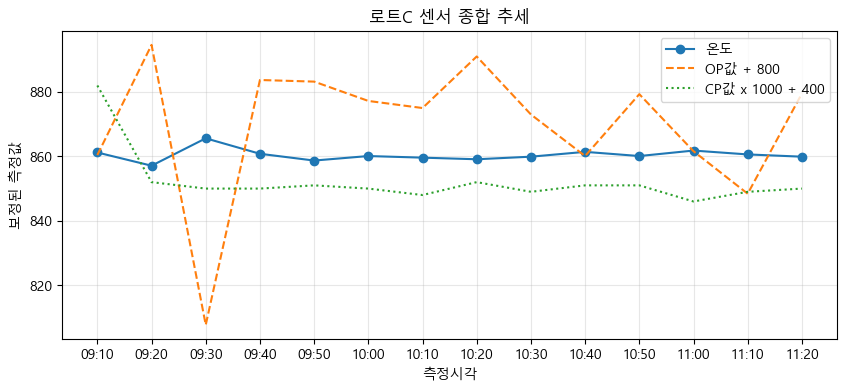

In [21]:
# 로트C의 온도, OP값, CP값을 한 그래프에 겹쳐 그리기
path_6 = os.path.join(DATA_DIR, "17_열처리.csv")
df_6 = pd.read_csv(path_6, encoding="utf-8")

df_6_c = df_6[df_6["배치"] == "로트C"]

# 단위가 서로 달라서 그냥 겹치면 한 선만 보임 -> 범위부터 확인
print(df_6_c[["온도", "OP값", "CP값"]].describe().round(3))

plt.figure(figsize=(10, 4))

# 단위가 다른 값은 배수를 곱하고 더해 눈에 보이게 보정
plt.plot(df_6_c["측정시각"], df_6_c["온도"], label="온도", marker="o")
plt.plot(df_6_c["측정시각"], df_6_c["OP값"] + 800, label="OP값 + 800", linestyle="--")
plt.plot(df_6_c["측정시각"], df_6_c["CP값"] * 1000 + 400, label="CP값 x 1000 + 400", linestyle=":")

# 제목, 축 이름, 범례로 완성하고 함께 움직이는지 관찰
plt.title("로트C 센서 종합 추세")
plt.xlabel("측정시각")
plt.ylabel("보정된 측정값")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

plt.savefig("17_01_실습6_로트C_센서종합.png", dpi=150, bbox_inches="tight")
plt.show()
